In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

GITHUB_REPO = "https://github.com/danokundaye/kidney-tumour-detection.git"
REPO_NAME = "kidney-tumour-detection"
CLONE_PATH = f"/content/{REPO_NAME}"

if os.path.exists(CLONE_PATH):
    print("Repository already exists, pulling latest changes...")
    os.chdir(CLONE_PATH)
    os.system("git pull origin main")
    print("Repository updated")
else:
    print("Cloning repository...")
    os.system(f"git clone {GITHUB_REPO} {CLONE_PATH}")
    print("Repository cloned")

if CLONE_PATH not in sys.path:
    sys.path.insert(0, CLONE_PATH)
    print(f"Added {CLONE_PATH} to Python path")

print(f"\nWorking directory: {CLONE_PATH}")
print("GitHub sync complete")

Mounted at /content/drive
Cloning repository...
Repository cloned
Added /content/kidney-tumour-detection to Python path

Working directory: /content/kidney-tumour-detection
GitHub sync complete


In [2]:
from pathlib import Path

PATCHES_DIR = '/content/drive/MyDrive/kidney-tumour-detection/results/phase9_pipeline/patches'

cases      = [d for d in sorted(Path(PATCHES_DIR).iterdir()) if d.is_dir()]
total_patches = sum(len(list(c.glob('*.png'))) for c in cases)

print(f'cases with patches : {len(cases)}')
print(f'total patches      : {total_patches}')
print(f'sample case        : {cases[0].name}')
print(f'patches in sample  : {len(list(cases[0].glob("*.png")))}')

cases with patches : 70
total patches      : 35492
sample case        : case_00001
patches in sample  : 512


In [4]:
import pandas as pd
from pathlib import Path

DRIVE_BASE = '/content/drive/MyDrive/kidney-tumour-detection'

pred_csv = f'{DRIVE_BASE}/results/phase9_pipeline/predictions.csv'
test_csv = f'{DRIVE_BASE}/dataset/processed/splits/test.csv'

df      = pd.read_csv(pred_csv)
test_df = pd.read_csv(test_csv)[['case_id', 'malignant']]

# merge to get malignant label alongside predictions
df = df.merge(test_df, on='case_id', how='left')

# cases that produced at least one contour patch
contour_cases = df[df['patches_contour'] > 0][['case_id', 'malignant',
                                                'patches_contour', 'pred_label',
                                                'dice_3d']].sort_values('patches_contour',
                                                                        ascending = False)
print(f'cases with contour patches : {len(contour_cases)}')
print(f'total contour patches      : {df["patches_contour"].sum()}')
print()
print(contour_cases.to_string(index = False))

cases with contour patches : 64
total contour patches      : 2636

   case_id  malignant  patches_contour pred_label  dice_3d
case_00088       True              277  malignant   0.6820
case_00049       True              120  malignant   0.0000
case_00001       True              105  malignant   0.0000
case_00293       True               99  malignant   0.2183
case_00091       True               81  malignant   0.0000
case_00102       True               78  malignant   0.0213
case_00184       True               76  malignant   0.0015
case_00241       True               75  malignant   0.0000
case_00207       True               68  malignant   0.0000
case_00292       True               66  malignant   0.1060
case_00096       True               63  malignant   0.0000
case_00097       True               61  malignant   0.0000
case_00099       True               60  malignant   0.0000
case_00146       True               60  malignant   0.1155
case_00141       True               59  malignan

In [5]:
import pandas as pd
from pathlib import Path

train_csv = '/content/drive/MyDrive/kidney-tumour-detection/dataset/processed/splits/efficientnet_train.csv'
df        = pd.read_csv(train_csv)

# check first 3 paths exist
for path in df['patch_path'].head(3):
    p = Path(path)
    print(f'{"exists" if p.exists() else "MISSING"} : {path}')

exists : /content/drive/MyDrive/kidney-tumour-detection/dataset/processed/patches/case_00223/malignant/slice_0320.png
exists : /content/drive/MyDrive/kidney-tumour-detection/dataset/processed/patches/case_00283/malignant/slice_0319.png
exists : /content/drive/MyDrive/kidney-tumour-detection/dataset/processed/patches/case_00139/malignant/slice_0149.png


In [11]:
# Step 8.1 - SHAP EfficientNet
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!python /content/kidney-tumour-detection/src/explainability/shap_efficientnet.py

From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
Already up to date.
Phase 8 - SHAP explainability for EfficientNet-B0
Started: 2026-02-24 13:42:49

Device: cuda

Loading model
  Loading EfficientNet-B0 from: /content/drive/MyDrive/kidney-tumour-detection/results/phase7_efficientnet/weights/best.pt
  EfficientNet loaded

Loading background patches
  Background patches loaded: 50

Loading test patches
  case_00088: 10 patches sampled from 512 available
  case_00293: 10 patches sampled from 512 available
  case_00292: 10 patches sampled from 512 available
  case_00146: 10 patches sampled from 512 available
  case_00049: 5 patches sampled from 512 available
  case_00001: 5 patches sampled from 512 available
  Total test patches loaded: 50

 Running inference
  Malignant predictions: 38 / 50

 Computing shap values
  Computing shap values for 50 patches in batches of 5
  batch 1: patches 1 to 5 done
  batch 2: patches 6 to 10 done
  

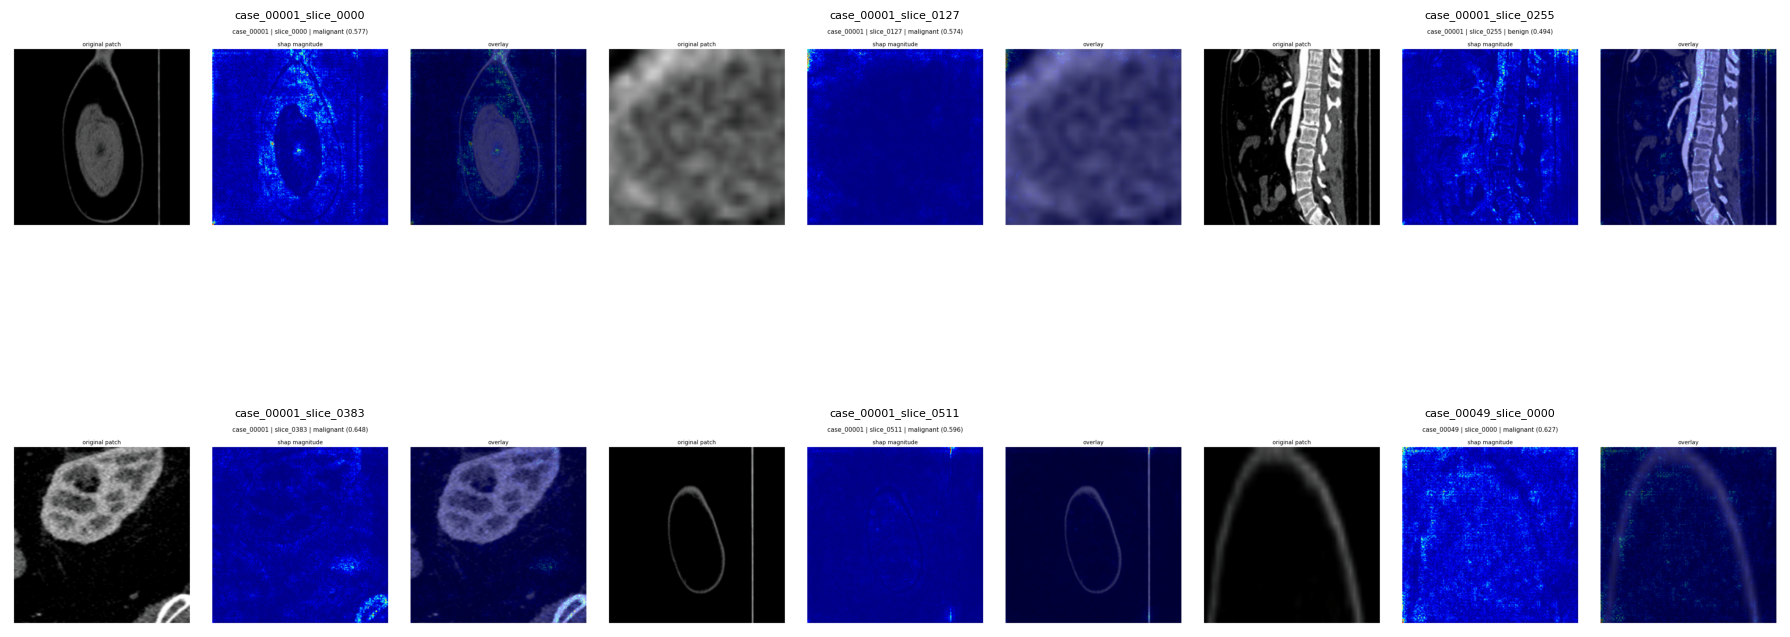

In [12]:
# Preview SHAP visualisations

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

VIS_DIR = '/content/drive/MyDrive/kidney-tumour-detection/results/phase8_shap/efficientnet/visualizations'

images = sorted(Path(VIS_DIR).glob('*.png'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, (ax, img_path) in enumerate(zip(axes.flatten(), images)):
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.set_title(img_path.stem, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [15]:
!pip install ultralytics -q
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.8 MB/s eta 0:00:00


In [16]:
import ultralytics
from ultralytics import YOLO
from pathlib import Path

print(f'ultralytics version: {ultralytics.__version__}')

DRIVE_BASE = '/content/drive/MyDrive/kidney-tumour-detection'
yolo_path  = f'{DRIVE_BASE}/results/phase5_yolo_retrain/yolov8s_retrain_run1/weights/best.pt'

model = YOLO(yolo_path)

# inspect internal pytorch model structure
internal = model.model
print(f'\ninternal model type: {type(internal)}')
print(f'internal model class: {internal.__class__.__name__}')

# check output of a dummy forward pass
import torch
dummy = torch.zeros(1, 3, 512, 512).to(next(internal.parameters()).device)
internal.eval()
with torch.no_grad():
    out = internal(dummy)

print(f'\ndummy forward output type: {type(out)}')
if isinstance(out, (list, tuple)):
    print(f'output length: {len(out)}')
    for i, o in enumerate(out):
        if hasattr(o, 'shape'):
            print(f'  out[{i}] shape: {o.shape}')
        elif isinstance(o, (list, tuple)):
            print(f'  out[{i}] is list/tuple of length {len(o)}')
            for j, oo in enumerate(o):
                if hasattr(oo, 'shape'):
                    print(f'    out[{i}][{j}] shape: {oo.shape}')
elif hasattr(out, 'shape'):
    print(f'output shape: {out.shape}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics version: 8.4.15

internal model type: <class 'ultralytics.nn.tasks.DetectionModel'>
internal model class: DetectionModel

dummy forward output type: <class 'tuple'>
output length: 2
  out[0] shape: torch.Size([1, 5, 5376])


In [20]:
# Step 8.1 - SHAP Combined
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!python /content/kidney-tumour-detection/src/explainability/shap_combined.py

From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
Already up to date.
Device: cuda

Loading models

Processing case_00088 Dice=0.682, best segmentation result)
  Finding representative slice...
  Selected: slice_0190.png
  efficientnet patch: slice_0190.png
  Building backgrounds...
  computing YOLO SHAP...
  computing U-Net SHAP...
  Computing EfficientNet SHAP...
  Generating visualisation...
  Saved: case_00088_slice_0190_combined.png

Processing case_00001 Dice=0.0, contrast case poor segmentation)
  Finding representative slice...
  Selected: slice_0370.png
  efficientnet patch: slice_0370.png
  Building backgrounds...
  computing YOLO SHAP...
  computing U-Net SHAP...
  Computing EfficientNet SHAP...
  Generating visualisation...
  Saved: case_00001_slice_0370_combined.png

Combined SHAP complete
Output directory: /content/drive/MyDrive/kidney-tumour-detection/results/phase8_shap/combined


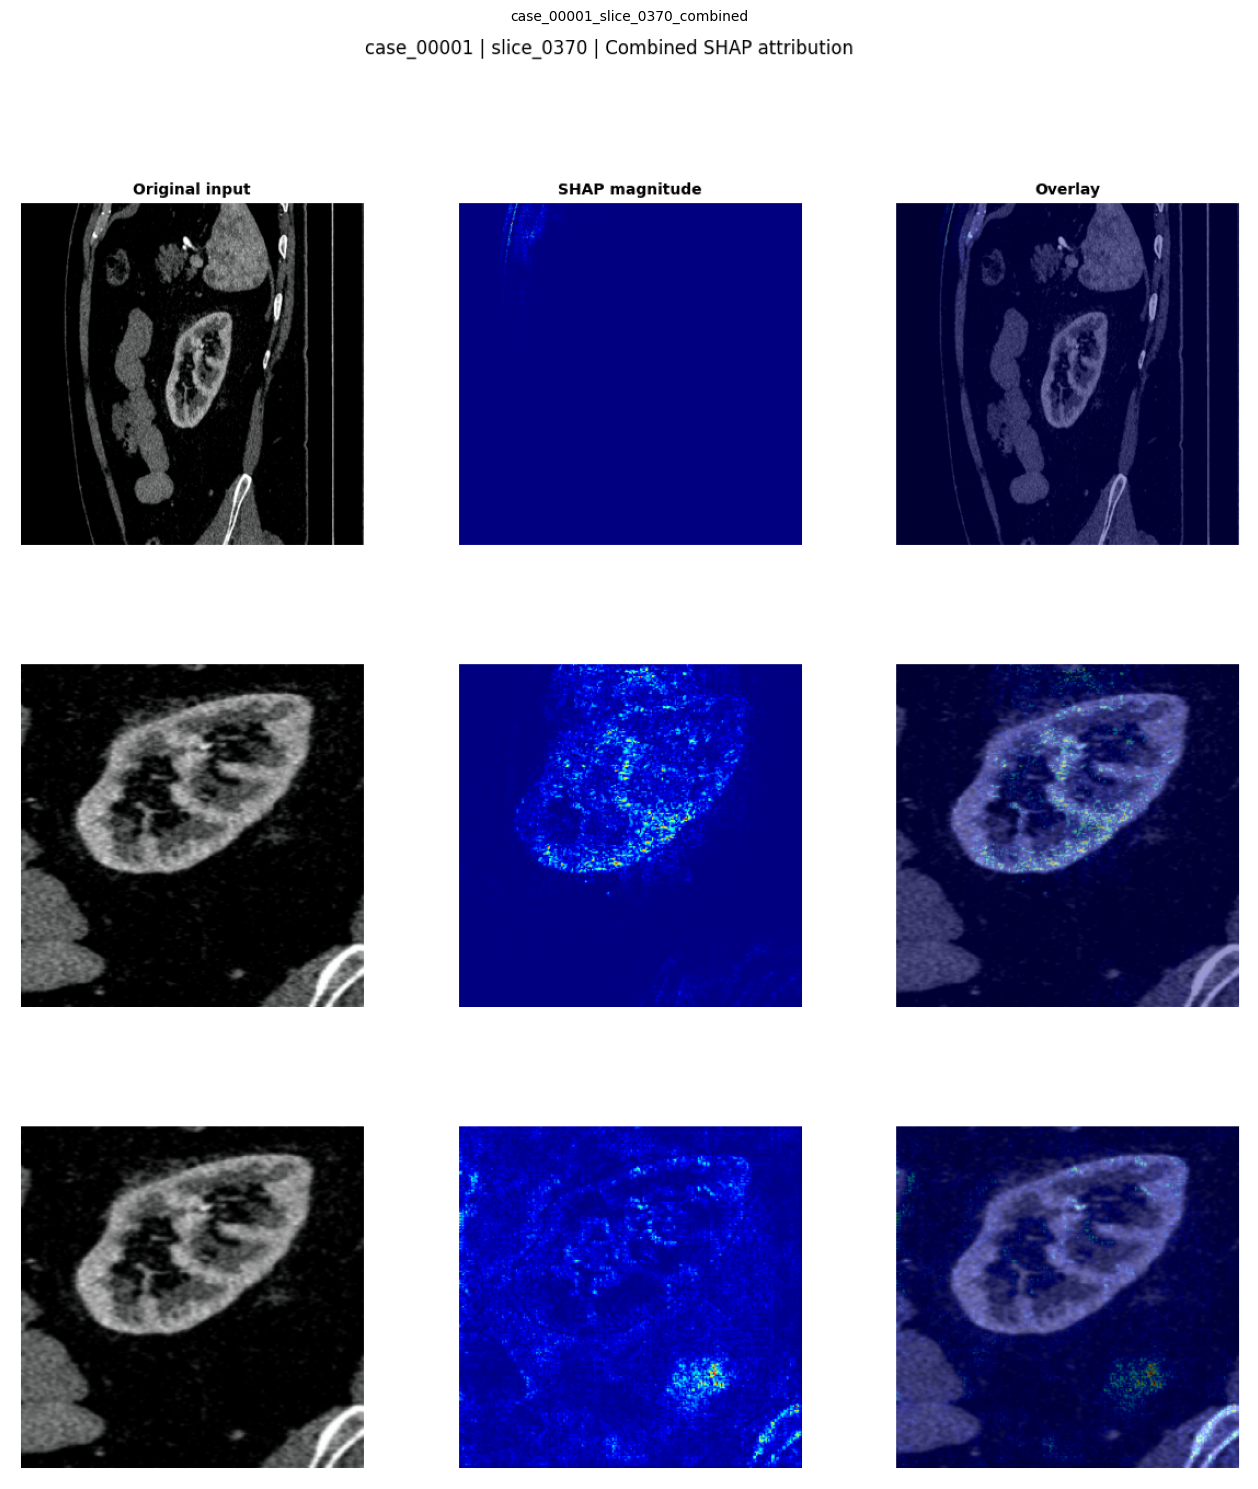

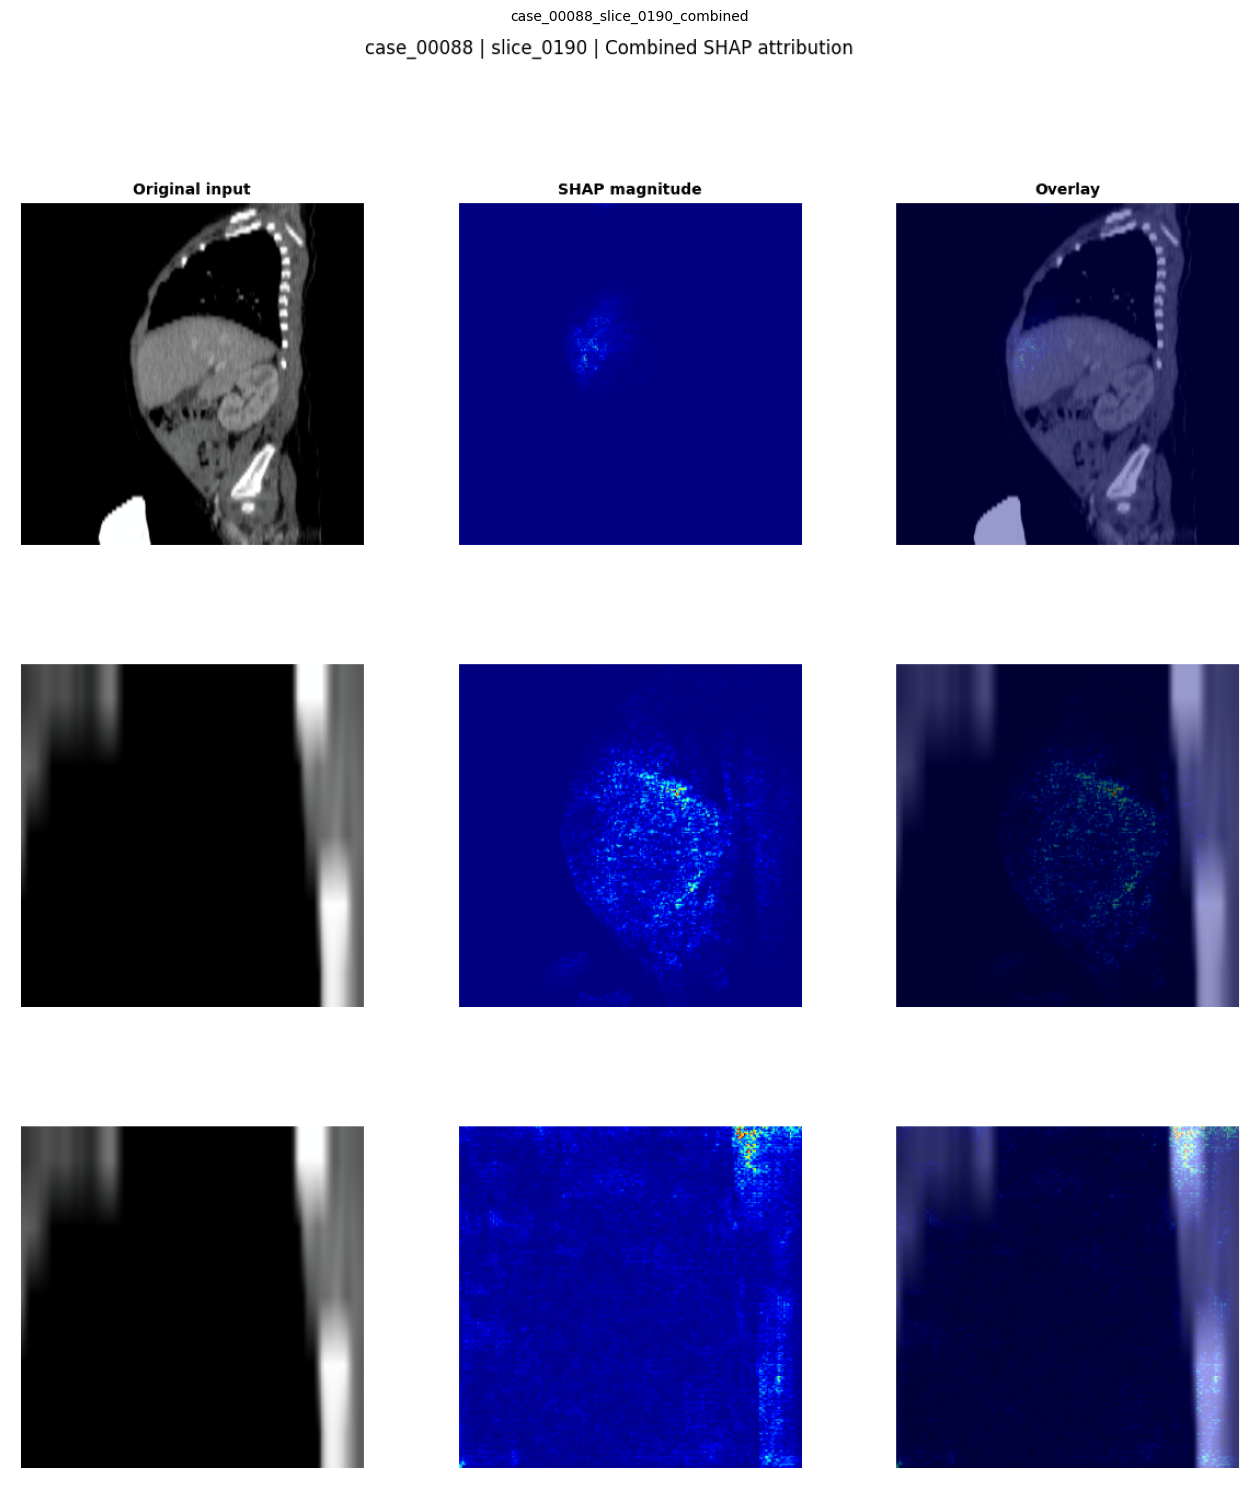

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

COMBINED_DIR = '/content/drive/MyDrive/kidney-tumour-detection/results/phase8_shap/combined'

images = sorted(Path(COMBINED_DIR).glob('*.png'))

for img_path in images:
    img = mpimg.imread(str(img_path))
    fig, ax = plt.subplots(1, 1, figsize=(18, 15))
    ax.imshow(img)
    ax.set_title(img_path.stem, fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()